# 1.softmax回归
回归可以预测多少的问题，例如预测房屋价格等。事实上，我们也对分类问题感兴趣：不是问“多少”，而是问“哪一个”。</br>
通常，机器学习实践者用**分类** 这个词来描述两个有微妙差别的问题：**(1)如果我们只对样本“硬性”类别感兴趣吗，就属于某个类别；（2）如果我们希望得到“软性”类别，就属于某个类别的概率。**
## 1.1 分类问题
我们从一个图像分类问题开始。假设每次输入是一个2像素$\times$2像素的灰度图像。我们可以用一个标量表示每个像素值，每张图像对应4个特征$x_1,x_2,x_3,x_4$。此外，假设每张图像属于类别猫、鸡和狗中的一个。</br>
接下来，我们要选择如何表示标签。我们有两个明显的选择。最直接的想法时选择$y \in {1, 2, 3}$，其中的整数分别对应狗、猫、鸡。这是在计算机上存储此类信息的有效方法。如果类别间有一定的自然顺序，例如我们试图预测{婴儿、儿童、青少年、中老人、老年人}，那么可以转变一个回归问题，并且保留这种格式是有意义的。</br>
但是一般分类问题**并不与类别之间的自然顺序有关**。一种表示分类数据的简单方法：**独热编码(one-hot encoding)**。独热编码是一个向量，**它的分量和类别一样多。类别分贝对应的分量设置为1，其他所有分量设置为0。在上述例子中，标签y将是一个三维向量，其中(1,0,0)对应猫，(0,1,0)对应鸡，(0,0,1)对应狗** ：
$$
y \in {(1, 0, 0), {0, 1, 0}, {0, 0, 1}}
$$
## 1.2 网络框架

为了估计所有可能类别的条件概率，**我们需要一个有多个输出的模型，每个类别对应一个输出。** 为了解决线性模型的分类问题，我们需要和输出一样多的 **仿射函数**。每个输出对应于它自己的仿射函数。在我们的例子中，我们有四个特征和三个可能的输出类别，我们将需要12个标量来表示权重（w表示），3个标量来表示偏执（b表示）。下面我们为每个输入计算3个未规范化的预测：$o_1,o_2,o_3$：
$$
o_1 = x_1w_{11} + x_2w_{12} + x_3w_{13} + x_4w_{14} + b_1 
$$
$$
o_2 = x_1w_{21} + x_2w_{22} + x_3w_{23} + x_4w_{24} + b_2
$$
$$
o_3 = x_1w_{31} + x_2w_{32} + x_3w_{33} + x_4w_{34} + b_3
$$

我们可以用神经网络图来描述这个计算过程，如下图所示。与线性回归一样，softmax也是一个单层神经网络。由于计算每个输出$o_1,o_2,o_3$取决于输入$x_1,x_2,x_3,x_4$。因此softmax回归的输出成也是一个**全连接层**。
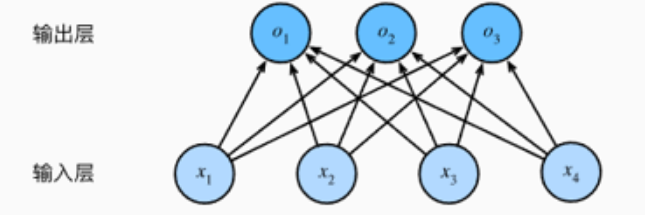

为了更简洁地表达模型，我们仍然使用线性代数符号。通过向量形式表示为$o = Wx + b$，这是一种更适合数学和编写代码的形式。我们已经将所有权重放到一个$3 \times 4$矩阵中。对于给定数据样本的特征x，我们的输出是由权重与输入特征进行矩阵-向量乘法再加上偏执b得到的。
## 1.3 全连接层的参数开销
全连接层是“完全”连接的，可能有很多可学习的参数。对于任何具有d个输入和q个输出的全连接层，参数开销为$O(dq)$，这个数字在实践中可能高得令人望而却步。但实际上我们可以将d个输入转换为q个输出得成本可以减少到$\frac{dq}{n}$，其中超参数n可以由我们灵活指定。
## 1.4 softmax运算
现在我们将优化参数以最大化观测数据得概率。为了得到预测结果，我们将设置一个阈值，如选择具有最大概率得标签。</br>
我们希望模型得输出$\hat y_j$可以视为属于类j得概率，然后选择具有最大输出值得类别$argmax_jy_j$作为我们得预测。例如，如果$\hat y_1, \hat y_2, \hat y_3$分别为0.1、0.8和0.1，那么我们预测的类别是2，在我们的例子中代表“鸡”。</br>
我们不能将**未规范化的预测$o$直接视作我们感兴趣的输出**。因为将线性层的输出直接视为概率时存在一些问题：</br>
$\cdot$ 我们没有限制这些输出数值的总和为1;</br>
$\cdot$ 根据输入的不同，输出值可以为负数，这在概率论是不可接受的;</br>

要将输出视为概率，我们必须保证在任何数据上的输出都是**非负的且总和为1。** 此外，我们需要一个训练的目标函数，来激励模型精准地估计概率。例如，在分类器输出0.5地所有样本中，我们希望这些样本中刚好有一半实际上属于预测类。这个属性叫作**校准**。

**softmax函数** 能够将未规范化地预测变换为非负数且总和为1，同时让模型保持可导地性质。为了实现这一目标，我们首先对每个未规范化地预测求幂，这样可以确保输出非负值。为了确保最终输出地概率值总和为1，我们再让每个求幂后的结果除以结果的总和，如下式：
$$
\hat y = softmax(o), 其中 \hat y_j = \frac{exp(o_j)}{\sum_{k} exp(o_k)}
$$
这里，对于所有的j总有$0 \le \hat y_j \le 1$。因此， $\hat y$可以视为一个正确的概率分布。softmax运算不会改变未规范化的预测$o$之间的大小次序，只会确定分配给每个类别的概率。因此，在预测过程中，我们仍然可以用下式来选择最有可能的类别：
$$
argmax_j \hat y_j = argmax_j o_j
$$
尽管softmax是一个非线性函数，但softmax回归的输出仍然由输入特征的仿射变换决定。因此，softmax回归是一个线性模型。

## 1.5 小批量样本的向量化
**为了提高计算效率并且充分利用GPU，我们通常会针对小批量样本的数据执行向量计算**。假设我们读取一个批量的样本X，其中特征维度为d，批量大小为n。此外，假设我们在输出中有q个类别。那么小批量样本的特征为$X \in R^{n \times d}$，权重为$W \in R^{d \times q}$，偏置为$b \in R^{1 \times q}$。softmax回归的向量计算表达式为：
$$
O = XW + b
$$
$$
\hat Y = softmax(O)
$$
相对于一次处理一个样本，小批量样本的向量化加快了XW的矩阵-向量乘法。由于X中的每一行代表一个数据样本，softmax运算可以按行执行：对于O的每一行，我们先对所有项进行幂运算，然后通过求和对他们进行标准化（归一化）。XW+b的求和会使用广播机制，小批量的未规范化预测O和输出概率$\hat Y$都是形状为$n \times q$的矩阵。

## 1.6 损失函数
接下来，我们需要一个损失函数来度量预测的效果。我们将使用极大似然估计（让模型参数尽可能让观测数据出现的概率最大），这与在线性回归中的方法相同。
### 1.对数似然
softmax函数给出了一个向量$\hat y$，我们可以将其视为“对给定任意输入x的每个类的条件概率”。例如，$\hat y_1 = P(y = 猫|x)$。假设整个数据集{X,Y}具有n个样本，其中索引i的样本由特征向量$x^{(i)}$和独热标签向量$y^{(i)}$组成。我们可以将估计值与实际值进行比较：
$$
P(Y|X) = \prod_{i = 1}^{n} P(y^{(i)}|x^{(i)})
$$
根据极大似然估计，我们最大化$P(Y|X)$，相当于最小化负对数似然：
$$
-logP(Y|X) = \sum_{i = 1}^{n}-logP(y^{(i)}|x^{(i)}) = \sum_{i = 1}^{n} l (y^{(i)}, \hat y^{(i)})
$$
其中，对于任何标签y和模型预测$\hat y$，损失函数为：
$$
l(y, \hat y) = -\sum_{j = 1}^{q} y_j log \hat y_j
$$

上式中的损失函数通常称为**交叉熵损失**。因为y是一个长度为q的**独热编码向量**，所以除以一个项以外的其他项j都消失了。由于所有$\hat y_j$都是预测概率，它们的对数永远不会大于0。因此，如果正确地预测实际标签，即实际标签$P(y|x) = 1$，则损失函数不能进一步最小化。

### 2.softmax及其导数
由于softmax和相关地损失函数很常见，因此我们需要更好地理解它地计算方式。如下所示：
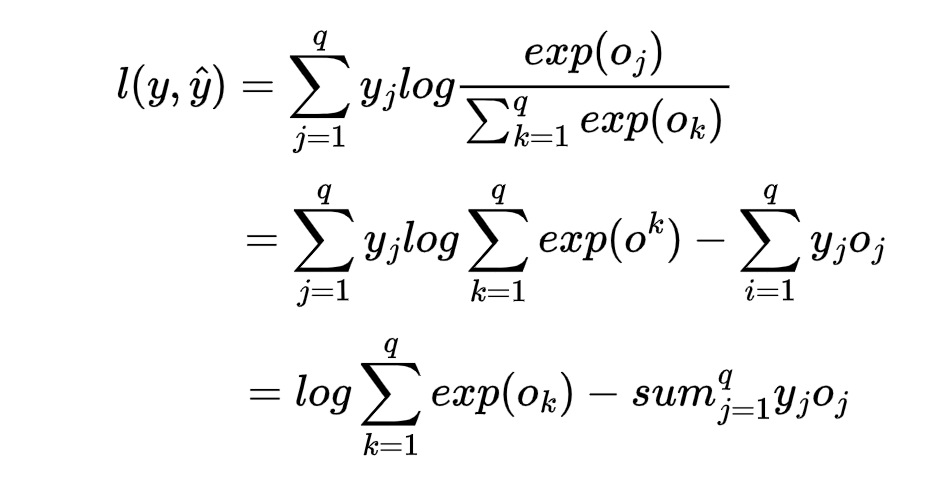

对于第二步到第三步中的疑问：由于y是独热编码，所以求和后就是1了。第三步就省略了。

考虑相对于任何未规范化的预测$o_j$的导数，我们得到：
$$
\partial_{o_j} l(y, \hat y) = \frac{exp(o_j)}{\sum_{i=1}^{q}exp(o_k)}-y_j = softmax(o)_j - y _j
$$

换句话说，**导数是我们softmax模型分配的概率与实际发生的情况（由独热标签向量表示）之间的差距。** 从这个意义出发，这与我们在回归中看到的非常相似，其中**梯度是观测值y和估计值$\hat y$ 之间的差距。** 对数似然的梯度由此得出。</br>

这一定是一个必然的结果！！！</br>
首先我们求的是一个概率，那么要求非负且总和为1，所以softmax由此设计是最合理的。并且符合了对数似然使其求导的结果达到我们的预期。

### 3 交叉熵损失
现在我们观察的结果与以往的区别就是我们现在用一个概率向量表示，如(0.1, 0.2, 0.7)。我们再使用上述提到的损失，它是所有标签分布的预期损失值，此损失称为**交叉熵损失。这是分类问题最常用的损失之一。** 
## 1.7 信息论基础
信息论涉及编码、解码、发送以及尽可能简洁地处理信息或数据。 
### 1. 熵
信息论地**核心思想是量化数据中地信息内容。** 在信息论中，该数值被称为分布P的熵。可以通过下式获得：
$$
H(P) = \sum_{j}-P(j)logP(j)
$$
信息论的基本定理之一指出，为了对从分布P中随机抽取的数据进行编码，我们至少需要$H(P)$“纳特”(nat)对其进行编码。纳特相当于比特。一个纳特是$\frac{2}{log(2)} \approx 1.44bit$
### 2.信息量
如果我们很容易预测下一个数据，那么这个数据就很容易压缩。但是，如果我们不能完全预测每个事件，那么我们有时可能会感到“惊异”。香农决定用信息量$log \frac{1}{P(j)} = -log P(j)$ 来量化这种惊异程度。在观测一个事件j时，赋予它概率P(j)。当我们赋予一个事件较低的概率时，我们的惊异程度会较大，该事件的信息量也就增大。
### 3.重新审视交叉熵
如果把熵$H(p)$想象为“知道真实概率的人所经历的惊异程度”，那交叉熵是从P到Q，记为H(P,Q)。可以想象为“主观概率为Q的观察者在看到P生成的数据时的预期惊异”。当P=Q时，交叉熵达到最小值。在这种情况下，从P到Q的交叉熵为H(P, Q) = H(P)。</br></br>
交叉熵衡量的是用主观概率分布Q去描述真实概率分布P生成的数据时，平均每次事件需要付出的“惊异程度”。举个例子：如果某地真实天气分布P是“晴天70%、阴天20%、下雨10%”，那么本地人根据真实概率感受到的平均惊异（熵）大约是0.8纳特；但一个外地人根据自己的主观分布Q（比如晴天30%、阴天30%、下雨40%）去预测天气时，平均惊异（交叉熵）会增加到1.18纳特——这多出来的0.38纳特就是因为Q偏离P而付出的“代价”。只有当Q完全等于P时，交叉熵才达到最小值，正好等于P的熵。
## 1.8 模型预测和评估
在训练softmax回归模型后，给出任何样本特征，我们就可以预测每个输出类别的概率。**通常我们使用预测概率最高的类别作为输出类别。** 